# cleaning

In [53]:
import pandas as pd
from pathlib import Path

base = Path(r"d:\Ace\tata_micro\quantin")

# Load customer purchase behavior data
df_purchase = pd.read_csv(base / "QVI_purchase_behaviour.csv")

# Load transaction data
df_transaction = pd.read_excel(base / "QVI_transaction_data.xlsx", sheet_name=0)

In [54]:
print("Purchase shape:", df_purchase.shape)
print(df_purchase.head())

Purchase shape: (72637, 3)
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004   OLDER SINGLES/COUPLES       Mainstream
4            1005  MIDAGE SINGLES/COUPLES       Mainstream


In [55]:
print("\nTransaction shape:", df_transaction.shape)
print(df_transaction.head())


Transaction shape: (264836, 8)
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


In [56]:
# Check for complete duplicates in each dataframe
print("Duplicate rows in purchase data:", df_purchase.duplicated().sum())
print("Duplicate rows in transaction data:", df_transaction.duplicated().sum())

# Remove complete duplicate rows
df_purchase = df_purchase.drop_duplicates()
df_transaction = df_transaction.drop_duplicates()

# Verify after removal
print("After removal - purchase shape:", df_purchase.shape)
print("After removal - transaction shape:", df_transaction.shape)

Duplicate rows in purchase data: 0
Duplicate rows in transaction data: 1
After removal - purchase shape: (72637, 3)
After removal - transaction shape: (264835, 8)


In [57]:
# Check for negative quantity and sales values
print("Negative QUANTITY values:", (df_transaction["PROD_QTY"] < 0).sum())
print("Negative TOTAL_SALES values:", (df_transaction["TOT_SALES"] < 0).sum())

Negative QUANTITY values: 0
Negative TOTAL_SALES values: 0


In [58]:
# Unique values count for purchase data
print("Unique values in df_purchase:")
print(df_purchase.nunique())

print("\nUnique values in df_transaction:")
print(df_transaction.nunique())

Unique values in df_purchase:
LYLTY_CARD_NBR      72637
LIFESTAGE               7
PREMIUM_CUSTOMER        3
dtype: int64

Unique values in df_transaction:
DATE                 364
STORE_NBR            272
LYLTY_CARD_NBR     72637
TXN_ID            263127
PROD_NBR             114
PROD_NAME            114
PROD_QTY               6
TOT_SALES            112
dtype: int64


In [59]:
df_purchase["PREMIUM_CUSTOMER"].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [60]:
# Check if any PROD_NBR has more than one PROD_NAME
prod_nbr_to_names = df_transaction.groupby("PROD_NBR")["PROD_NAME"].nunique()
multi_name_prods = prod_nbr_to_names[prod_nbr_to_names > 1]

print("PROD_NBR with more than one PROD_NAME:")
print(multi_name_prods)

# Check if any PROD_NAME has more than one PROD_NBR
prod_name_to_numbers = df_transaction.groupby("PROD_NAME")["PROD_NBR"].nunique()
multi_number_prods = prod_name_to_numbers[prod_name_to_numbers > 1]

print("\nPROD_NAME with more than one PROD_NBR:")
print(multi_number_prods)

PROD_NBR with more than one PROD_NAME:
Series([], Name: PROD_NAME, dtype: int64)

PROD_NAME with more than one PROD_NBR:
Series([], Name: PROD_NBR, dtype: int64)


In [61]:
print("\nMapping of PROD_NBR to PROD_NAME:")
print(df_transaction.groupby("PROD_NBR")["PROD_NAME"].unique())


Mapping of PROD_NBR to PROD_NAME:
PROD_NBR
1       [Smiths Crinkle Cut  Chips Barbecue 170g]
2        [Cobs Popd Sour Crm  &Chives Chips 110g]
3      [Kettle Sensations   Camembert & Fig 150g]
4              [Dorito Corn Chp     Supreme 380g]
5        [Natural Chip        Compny SeaSalt175g]
                          ...                    
110              [WW Original Corn    Chips 200g]
111       [Smiths Chip Thinly  Cut Original 175g]
112      [Tyrrells Crisps     Ched & Chives 165g]
113                        [Twisties Chicken270g]
114       [Kettle Sensations   Siracha Lime 150g]
Name: PROD_NAME, Length: 114, dtype: object


In [62]:
# Extract the final word/number part of each product name
df_transaction["prod_name_lower"] = df_transaction["PROD_NAME"].astype(str).str.strip().str.lower()

# Check if name ends with a weight pattern like 170g, 110g, 150g, 200g, 350ml, etc.
pattern = r".*\b\d+(g|kg|ml|l)\s*$"

df_transaction["ends_with_weight"] = df_transaction["prod_name_lower"].str.match(pattern, na=False)

print("Names that end with weight:")
print(df_transaction[df_transaction["ends_with_weight"]][["PROD_NBR", "PROD_NAME"]].drop_duplicates())

print("\nNames that do NOT end with weight:")
print(df_transaction[~df_transaction["ends_with_weight"]][["PROD_NBR", "PROD_NAME"]].drop_duplicates())

Names that end with weight:
     PROD_NBR                                 PROD_NAME
1          66                  CCs Nacho Cheese    175g
2          61    Smiths Crinkle Cut  Chips Chicken 170g
3          69    Smiths Chip Thinly  S/Cream&Onion 175g
4         108  Kettle Tortilla ChpsHny&Jlpno Chili 150g
5          57  Old El Paso Salsa   Dip Tomato Mild 300g
..        ...                                       ...
520        58     Red Rock Deli Chikn&Garlic Aioli 150g
521        10       RRD SR Slow Rst     Pork Belly 150g
528        11                  RRD Pc Sea Salt     165g
549        43        Smith Crinkle Cut   Bolognese 150g
689        41                  Doritos Salsa Mild  300g

[106 rows x 2 columns]

Names that do NOT end with weight:
     PROD_NBR                                 PROD_NAME
0           5    Natural Chip        Compny SeaSalt175g
35         37  Smiths Thinly       Swt Chli&S/Cream175G
40        106    Natural ChipCo      Hony Soy Chckn175g
42        113   

In [63]:
# Clean product number and product name
df_transaction["PROD_NBR"] = df_transaction["PROD_NBR"].astype(str).str.strip()
df_transaction["PROD_NAME"] = df_transaction["PROD_NAME"].astype(str).str.strip().str.lower()

# Remove repeated internal whitespace (double spaces, etc.)
df_transaction["PROD_NAME"] = df_transaction["PROD_NAME"].replace(r"\s+", " ", regex=True)

In [64]:
import re

def add_space_before_weight(name):
    name = str(name).strip()
    if re.search(r"\d{3,4}(g|kg|ml|l)$", name, flags=re.I):
        return re.sub(r"(\d{3,4}(g|kg|ml|l))$", r" \1", name)
    return name

df_transaction["PROD_NAME"] = df_transaction["PROD_NAME"].apply(add_space_before_weight)

print(df_transaction[df_transaction["PROD_NAME"].str.contains(r"\d{3,4}(g|kg|ml|l)$", regex=True, case=False)]
        [["PROD_NBR", "PROD_NAME"]].drop_duplicates())

C:\Users\HP\AppData\Local\Temp\ipykernel_12504\1271496732.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  print(df_transaction[df_transaction["PROD_NAME"].str.contains(r"\d{3,4}(g|kg|ml|l)$", regex=True, case=False)]


    PROD_NBR                                  PROD_NAME
0          5           natural chip compny seasalt 175g
1         66                     ccs nacho cheese  175g
2         61     smiths crinkle cut chips chicken  170g
3         69     smiths chip thinly s/cream&onion  175g
4        108  kettle tortilla chpshny&jlpno chili  150g
..       ...                                        ...
520       58     red rock deli chikn&garlic aioli  150g
521       10           rrd sr slow rst pork belly  150g
528       11                      rrd pc sea salt  165g
549       43          smith crinkle cut bolognese  150g
689       41                   doritos salsa mild  300g

[110 rows x 2 columns]


In [65]:
df_transaction.loc[df_transaction["PROD_NAME"] == "kettle 135g swt pot sea salt", "PROD_NAME"] = "kettle swt pot sea salt 135g"

In [66]:
import re

# Check names ending with kg / ml / l
kg_ml_l = df_transaction["PROD_NAME"].str.contains(r"(kg|ml|l)\s*$", case=False, na=False)
print("Product names ending with kg/ml/l:")
print(df_transaction.loc[kg_ml_l, ["PROD_NBR", "PROD_NAME"]].drop_duplicates())

# Check names ending with a grams weight pattern like 175g or 300g
grams_pattern = r"\b\d{1,4}g\s*$"
grams_names = df_transaction["PROD_NAME"].str.contains(grams_pattern, case=False, na=False)

print("\nProduct names ending with grams:")
print(df_transaction.loc[grams_names, ["PROD_NBR", "PROD_NAME"]].drop_duplicates())

# Check whether all names that contain a weight end with a 3-digit grams pattern
# (for example 175g, 300g, 135g)
weight_like = df_transaction["PROD_NAME"].str.contains(r"\b\d{1,4}(g|kg|ml|l)\b", case=False, na=False)

print("\nAre all weight-containing names in grams with 3 digits?")
print(df_transaction.loc[weight_like, "PROD_NAME"].str.match(r".*\b\d{3}g\s*$", case=False, na=False).all())

C:\Users\HP\AppData\Local\Temp\ipykernel_12504\889701163.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  kg_ml_l = df_transaction["PROD_NAME"].str.contains(r"(kg|ml|l)\s*$", case=False, na=False)


Product names ending with kg/ml/l:
Empty DataFrame
Columns: [PROD_NBR, PROD_NAME]
Index: []

Product names ending with grams:
    PROD_NBR                                  PROD_NAME
0          5           natural chip compny seasalt 175g
1         66                     ccs nacho cheese  175g
2         61     smiths crinkle cut chips chicken  170g
3         69     smiths chip thinly s/cream&onion  175g
4        108  kettle tortilla chpshny&jlpno chili  150g
..       ...                                        ...
520       58     red rock deli chikn&garlic aioli  150g
521       10           rrd sr slow rst pork belly  150g
528       11                      rrd pc sea salt  165g
549       43          smith crinkle cut bolognese  150g
689       41                   doritos salsa mild  300g

[114 rows x 2 columns]


C:\Users\HP\AppData\Local\Temp\ipykernel_12504\889701163.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  weight_like = df_transaction["PROD_NAME"].str.contains(r"\b\d{1,4}(g|kg|ml|l)\b", case=False, na=False)



Are all weight-containing names in grams with 3 digits?
False


In [67]:
import re

def extract_weight(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    m = re.search(r'(\d+)\s*g\s*$', name, flags=re.I)
    if m:
        return int(m.group(1))
    return None

df_transaction["WEIGHT"] = df_transaction["PROD_NAME"].apply(extract_weight)

# Remove the trailing weight from PROD_NAME
df_transaction["PROD_NAME"] = (
    df_transaction["PROD_NAME"]
    .str.replace(r"\s*\d+\s*g\s*$", "", regex=True)
    .str.strip()
)

# Make sure it is numeric
df_transaction["WEIGHT"] = pd.to_numeric(df_transaction["WEIGHT"], errors="coerce")

df_transaction[["PROD_NAME", "WEIGHT"]].head()

,PROD_NAME,WEIGHT
0,natural chip compny seasalt,175
1,ccs nacho cheese,175
2,smiths crinkle cut chips chicken,170
3,smiths chip thinly s/cream&onion,175
4,kettle tortilla chpshny&jlpno chili,150


In [68]:
print("\nMapping of PROD_NBR to PROD_NAME:")
print(df_transaction.groupby("PROD_NBR")["PROD_NAME"].unique())


Mapping of PROD_NBR to PROD_NAME:
PROD_NBR
1       [smiths crinkle cut chips barbecue]
10             [rrd sr slow rst pork belly]
100    [smiths crinkle cut chips chs&onion]
101                  [doritos salsa medium]
102       [kettle mozzarella basil & pesto]
                       ...                 
95      [sunbites whlegrn crisps frch/onin]
96              [ww original stacked chips]
97                     [rrd salt & vinegar]
98         [ncc sour cream & garden chives]
99            [pringles sthrn friedchicken]
Name: PROD_NAME, Length: 114, dtype: object


In [69]:
# Get card numbers from both datasets
purchase_cards = set(df_purchase["LYLTY_CARD_NBR"])
transaction_cards = set(df_transaction["LYLTY_CARD_NBR"])

# Cards in purchase data but missing from transaction data
missing_in_transactions = purchase_cards - transaction_cards

# Cards in transaction data but missing from purchase data
missing_in_purchase = transaction_cards - purchase_cards

print("Cards in purchase but not in transactions:", len(missing_in_transactions))
print(sorted(missing_in_transactions)[:20])

print("\nCards in transactions but not in purchase:", len(missing_in_purchase))
print(sorted(missing_in_purchase)[:20])

Cards in purchase but not in transactions: 0
[]

Cards in transactions but not in purchase: 0
[]


In [70]:
# Keep only the needed purchase columns and remove duplicates by card number
# df_transaction = df_transaction.drop(columns=["prod_name_lower", "ends_with_weight"])

purchase_lookup = (
    df_purchase[["LYLTY_CARD_NBR", "LIFESTAGE", "PREMIUM_CUSTOMER"]]
    .drop_duplicates(subset=["LYLTY_CARD_NBR"])
)

# Merge transaction data with purchase attributes
final_df = df_transaction.merge(
    purchase_lookup,
    on="LYLTY_CARD_NBR",
    how="left"
)

print(final_df.shape)
print(final_df.head())
print("\nMissing LIFESTAGE values:", final_df["LIFESTAGE"].isna().sum())
print("Missing PREMIUM_CUSTOMER values:", final_df["PREMIUM_CUSTOMER"].isna().sum())


(264835, 13)
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID PROD_NBR  \
0  43390          1            1000       1        5   
1  43599          1            1307     348       66   
2  43605          1            1343     383       61   
3  43329          2            2373     974       69   
4  43330          2            2426    1038      108   

                             PROD_NAME  PROD_QTY  TOT_SALES  \
0          natural chip compny seasalt         2        6.0   
1                     ccs nacho cheese         3        6.3   
2     smiths crinkle cut chips chicken         2        2.9   
3     smiths chip thinly s/cream&onion         5       15.0   
4  kettle tortilla chpshny&jlpno chili         3       13.8   

                            prod_name_lower  ends_with_weight  WEIGHT  \
0    natural chip        compny seasalt175g             False     175   
1                  ccs nacho cheese    175g              True     175   
2    smiths crinkle cut  chips chicken 170g         

# analysis

In [71]:
df = final_df

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [73]:


# ==============================
# BASIC OVERVIEW
# ==============================

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Number of transactions: {len(df):,}")
print(f"Number of stores: {df['STORE_NBR'].nunique()}")
print(f"Number of customers: {df['LYLTY_CARD_NBR'].nunique()}")
print(f"Number of products: {df['PROD_NBR'].nunique()}")

print("\nTotal Sales:")
print(df['TOT_SALES'].sum())

print("\nTotal Quantity Sold:")
print(df['PROD_QTY'].sum())

print("\nAverage Transaction Value:")
print(df['TOT_SALES'].mean())



DATASET OVERVIEW
Number of transactions: 264,835
Number of stores: 272
Number of customers: 72637
Number of products: 114

Total Sales:
1934408.9999999998

Total Quantity Sold:
505122

Average Transaction Value:
7.3042045046916


In [74]:
# ==============================
# SALES BY CUSTOMER SEGMENT
# ==============================

segment_sales = (
    df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Total_Qty=('PROD_QTY','sum'),
          Transactions=('TXN_ID','count'),
          Customers=('LYLTY_CARD_NBR','nunique')
      )
      .reset_index()
)

segment_sales['Sales_per_Customer'] = (
    segment_sales['Total_Sales'] /
    segment_sales['Customers']
)

segment_sales = segment_sales.sort_values(
    by='Total_Sales',
    ascending=False
)

print("\n\nSALES BY CUSTOMER SEGMENT")
print(segment_sales)

segment_sales.to_csv("segment_sales.csv", index=False)




SALES BY CUSTOMER SEGMENT
                 LIFESTAGE PREMIUM_CUSTOMER  Total_Sales  Total_Qty  \
6           OLDER FAMILIES           Budget    168363.25      45065   
19   YOUNG SINGLES/COUPLES       Mainstream    157621.60      38632   
13                RETIREES       Mainstream    155677.05      40518   
15          YOUNG FAMILIES           Budget    139345.85      37111   
9    OLDER SINGLES/COUPLES           Budget    136769.80      35220   
10   OLDER SINGLES/COUPLES       Mainstream    133393.80      34997   
11   OLDER SINGLES/COUPLES          Premium    132257.15      33984   
12                RETIREES           Budget    113147.80      28764   
7           OLDER FAMILIES       Mainstream    103445.55      27756   
14                RETIREES          Premium     97646.05      24884   
16          YOUNG FAMILIES       Mainstream     92788.75      25044   
1   MIDAGE SINGLES/COUPLES       Mainstream     90803.85      22699   
17          YOUNG FAMILIES          Premium     8

In [75]:
segment_sales = (
    df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Customers=('LYLTY_CARD_NBR','nunique'),
          Transactions=('TXN_ID','count'),
          Quantity=('PROD_QTY','sum')
      )
      .reset_index()
)

segment_sales['Sales_Per_Customer'] = (
    segment_sales['Total_Sales'] /
    segment_sales['Customers']
)

segment_sales['Avg_Transaction_Value'] = (
    segment_sales['Total_Sales'] /
    segment_sales['Transactions']
)

segment_sales = segment_sales.sort_values(
    'Total_Sales',
    ascending=False
)

print(segment_sales.head(5))

                LIFESTAGE PREMIUM_CUSTOMER  Total_Sales  Customers  \
6          OLDER FAMILIES           Budget    168363.25       4675   
19  YOUNG SINGLES/COUPLES       Mainstream    157621.60       8088   
13               RETIREES       Mainstream    155677.05       6479   
15         YOUNG FAMILIES           Budget    139345.85       4017   
9   OLDER SINGLES/COUPLES           Budget    136769.80       4929   

    Transactions  Quantity  Sales_Per_Customer  Avg_Transaction_Value  
6          23160     45065           36.013529               7.269570  
19         20854     38632           19.488328               7.558339  
13         21466     40518           24.027944               7.252262  
15         19122     37111           34.689034               7.287201  
9          18407     35220           27.747981               7.430315  


In [76]:
drivers = (
    df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
      .agg(
          Sales=('TOT_SALES','sum'),
          Quantity=('PROD_QTY','sum'),
          Transactions=('TXN_ID','count'),
          Customers=('LYLTY_CARD_NBR','nunique')
      )
      .reset_index()
)

drivers['Transactions_Per_Customer'] = (
    drivers['Transactions'] /
    drivers['Customers']
)

drivers['Qty_Per_Transaction'] = (
    drivers['Quantity'] /
    drivers['Transactions']
)

drivers['Sales_Per_Transaction'] = (
    drivers['Sales'] /
    drivers['Transactions']
)

print(
    drivers.sort_values(
        'Sales',
        ascending=False
    ).head(5)
)

                LIFESTAGE PREMIUM_CUSTOMER      Sales  Quantity  Transactions  \
6          OLDER FAMILIES           Budget  168363.25     45065         23160   
19  YOUNG SINGLES/COUPLES       Mainstream  157621.60     38632         20854   
13               RETIREES       Mainstream  155677.05     40518         21466   
15         YOUNG FAMILIES           Budget  139345.85     37111         19122   
9   OLDER SINGLES/COUPLES           Budget  136769.80     35220         18407   

    Customers  Transactions_Per_Customer  Qty_Per_Transaction  \
6        4675                   4.954011             1.945812   
19       8088                   2.578388             1.852498   
13       6479                   3.313166             1.887543   
15       4017                   4.760269             1.940749   
9        4929                   3.734429             1.913403   

    Sales_Per_Transaction  
6                7.269570  
19               7.558339  
13               7.252262  
15        



LIFESTAGE SALES
                        Total_Sales  Customers
LIFESTAGE                                     
OLDER SINGLES/COUPLES     402420.75      14609
RETIREES                  366470.90      14805
OLDER FAMILIES            353767.20       9780
YOUNG FAMILIES            316160.10       9178
YOUNG SINGLES/COUPLES     260405.30      14441
MIDAGE SINGLES/COUPLES    184751.30       7275
NEW FAMILIES               50433.45       2549


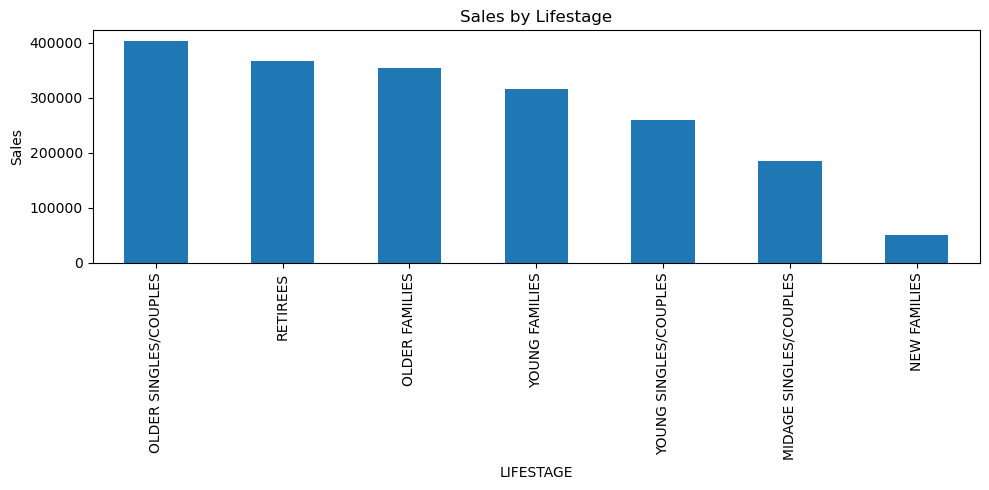

In [77]:
# ==============================
# TOP LIFESTAGES
# ==============================

lifestage_sales = (
    df.groupby('LIFESTAGE')
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Customers=('LYLTY_CARD_NBR','nunique')
      )
      .sort_values('Total_Sales', ascending=False)
)

print("\n\nLIFESTAGE SALES")
print(lifestage_sales)

plt.figure(figsize=(10,5))
lifestage_sales['Total_Sales'].plot(kind='bar')
plt.title("Sales by Lifestage")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()




PREMIUM CUSTOMER SALES
                  Total_Sales  Customers
PREMIUM_CUSTOMER                        
Mainstream          750744.50      29245
Budget              676211.55      24470
Premium             507452.95      18922


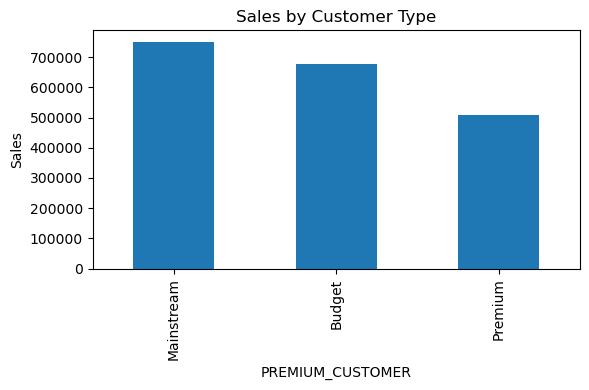

In [78]:
# ==============================
# PREMIUM CUSTOMER ANALYSIS
# ==============================

premium_sales = (
    df.groupby('PREMIUM_CUSTOMER')
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Customers=('LYLTY_CARD_NBR','nunique')
      )
      .sort_values('Total_Sales', ascending=False)
)

print("\n\nPREMIUM CUSTOMER SALES")
print(premium_sales)

plt.figure(figsize=(6,4))
premium_sales['Total_Sales'].plot(kind='bar')
plt.title("Sales by Customer Type")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()




TOP 15 PRODUCTS
                                     Total_Sales  Total_Qty
PROD_NAME                                                  
dorito corn chp supreme                  40352.0       6509
smiths crnkle chip orgnl big bag         36367.6       6164
smiths crinkle chips salt & vinegar      34804.2       6106
kettle mozzarella basil & pesto          34457.4       6381
smiths crinkle original                  34302.6       6018
cheezels cheese                          34296.9       6017
doritos cheese supreme                   33390.6       5858
kettle sweet chilli and sour cream       33031.8       6120
kettle original                          32740.2       6064
kettle sea salt and vinegar              32589.0       6035
kettle honey soy chicken                 32578.2       6033
kettle chilli                            31271.4       5792
old el paso salsa dip chnky tom ht       30513.3       5986
old el paso salsa dip tomato med         30237.9       5929
old el paso salsa dip 

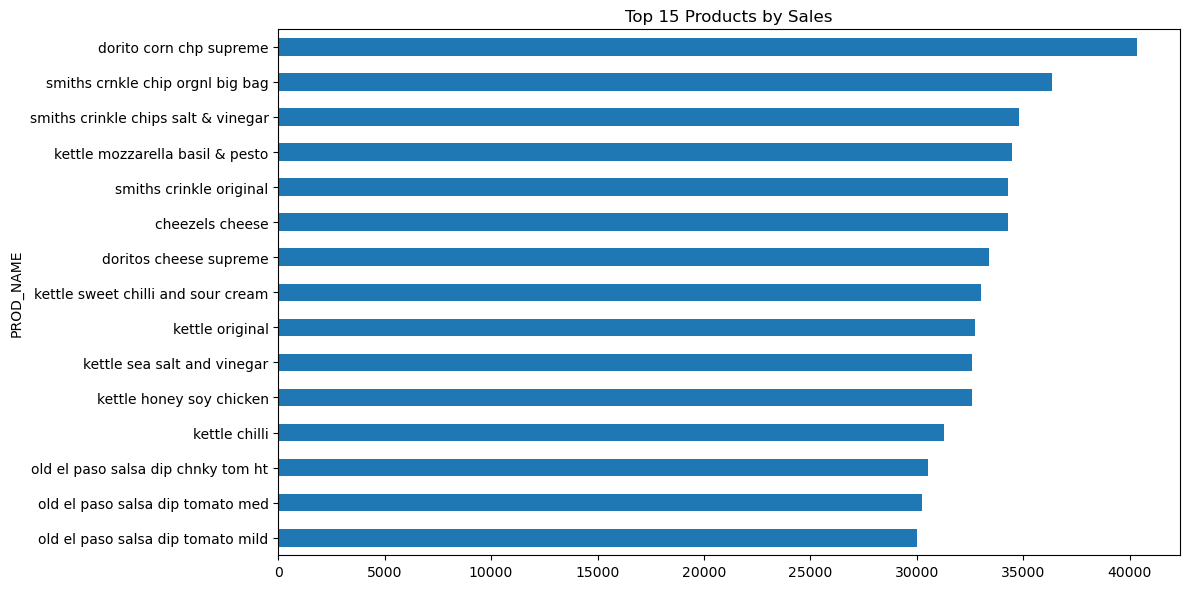

In [79]:
# ==============================
# TOP SELLING PRODUCTS
# ==============================

top_products = (
    df.groupby('PROD_NAME')
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Total_Qty=('PROD_QTY','sum')
      )
      .sort_values('Total_Sales', ascending=False)
      .head(15)
)

print("\n\nTOP 15 PRODUCTS")
print(top_products)

plt.figure(figsize=(12,6))
top_products['Total_Sales'].sort_values().plot(kind='barh')
plt.title("Top 15 Products by Sales")
plt.tight_layout()
plt.show()



TOP BRANDS
           Total_Sales  Quantity
BRAND                           
kettle        390239.8     79051
smiths        210070.8     54728
doritos       201538.9     47707
pringles      177655.5     48019
old            90785.1     17805
thins          88852.5     26929
twisties       81522.1     18118
tostitos       79789.6     18134
infuzions      76247.6     21119
cobs           70569.8     18571
rrd            64954.5     22500
tyrrells       51647.4     12298
grain          43048.8     11962
dorito         40352.0      6509
cheezels       40029.9      8747


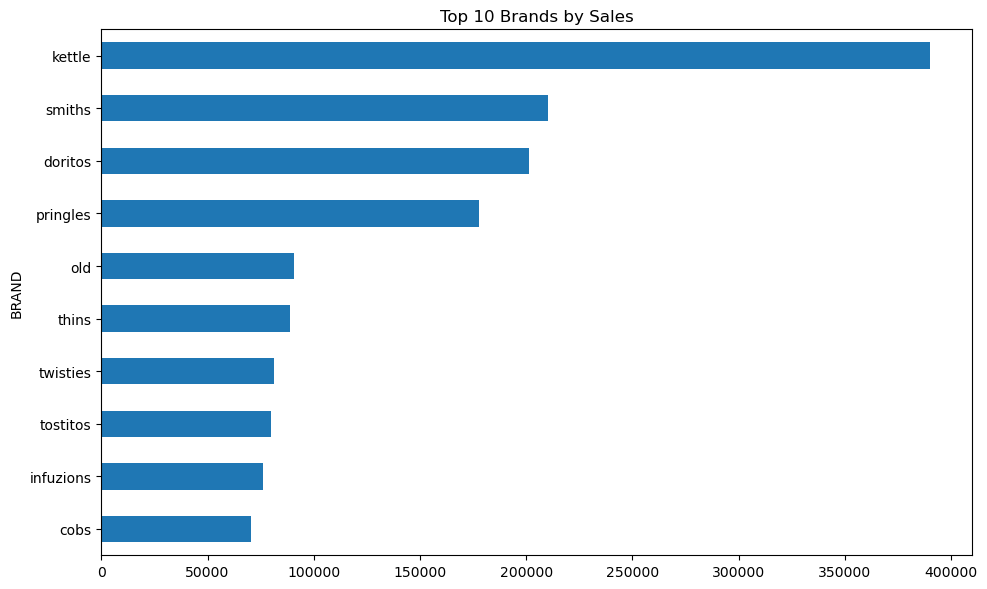

In [80]:
# ==============================
# BRAND ANALYSIS
# ==============================

df['BRAND'] = df['PROD_NAME'].str.split().str[0]

brand_sales = (
    df.groupby('BRAND')
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Quantity=('PROD_QTY','sum')
      )
      .sort_values('Total_Sales', ascending=False)
)

print("\n\nTOP BRANDS")
print(brand_sales.head(15))

plt.figure(figsize=(10,6))
brand_sales.head(10)['Total_Sales'].sort_values().plot(kind='barh')
plt.title("Top 10 Brands by Sales")
plt.tight_layout()
plt.show()



PACK SIZE ANALYSIS
        Total_Sales  Quantity
WEIGHT                       
175        485431.4    126465
150        304288.5     82174
134        177655.5     48019
110        162765.4     42835
170        146673.0     38088
330        136794.3     23999
300        113330.6     28813
165        101360.6     29051
380         76719.6     12673
270         55425.4     12049
210         43048.8     11962
250         26096.7      6069
135         26090.4      6212
200         16007.5      8425
190         14412.9      5673
160         10647.6      5604
90           9676.4      5692
180          8568.4      2764
70           6852.0      2855
220          6831.0      2970


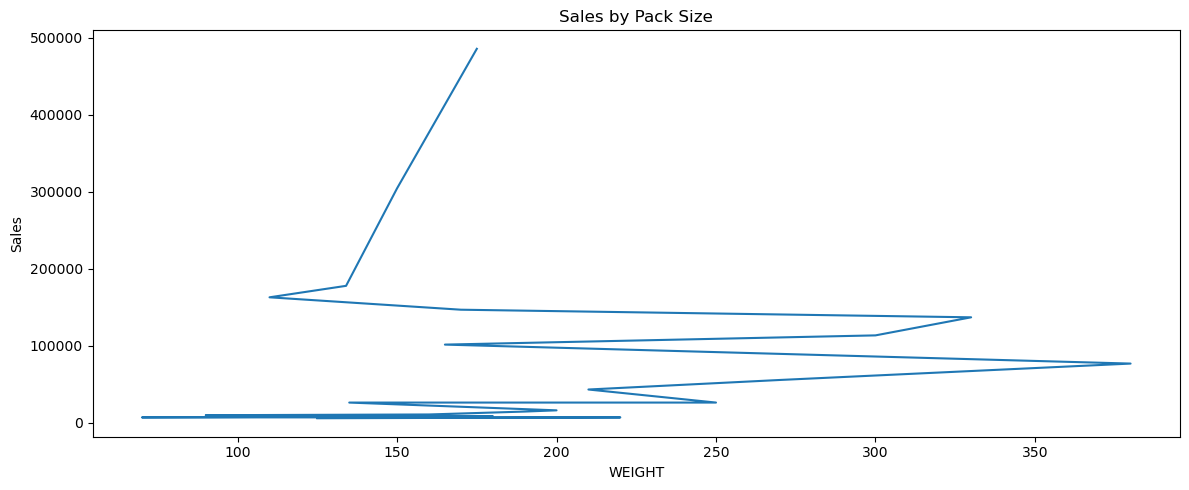

In [81]:
# ==============================
# PACK SIZE ANALYSIS
# ==============================

pack_size = (
    df.groupby('WEIGHT')
      .agg(
          Total_Sales=('TOT_SALES','sum'),
          Quantity=('PROD_QTY','sum')
      )
      .sort_values('Total_Sales', ascending=False)
)

print("\n\nPACK SIZE ANALYSIS")
print(pack_size.head(20))

plt.figure(figsize=(12,5))
pack_size['Total_Sales'].plot()
plt.title("Sales by Pack Size")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [82]:
# ==============================
# SEGMENT DRIVERS
# ==============================

segment_drivers = (
    df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])
      .agg(
          Sales=('TOT_SALES','sum'),
          Quantity=('PROD_QTY','sum'),
          Transactions=('TXN_ID','count'),
          Customers=('LYLTY_CARD_NBR','nunique')
      )
      .reset_index()
)

segment_drivers['Avg_Transaction_Value'] = (
    segment_drivers['Sales'] /
    segment_drivers['Transactions']
)

segment_drivers['Avg_Qty_Per_Transaction'] = (
    segment_drivers['Quantity'] /
    segment_drivers['Transactions']
)

segment_drivers['Sales_Per_Customer'] = (
    segment_drivers['Sales'] /
    segment_drivers['Customers']
)

print("\n\nSEGMENT DRIVERS")
print(
    segment_drivers.sort_values(
        'Sales',
        ascending=False
    )
)
segment_drivers.to_csv("segment_drivers.csv", index=False)




SEGMENT DRIVERS
                 LIFESTAGE PREMIUM_CUSTOMER      Sales  Quantity  \
6           OLDER FAMILIES           Budget  168363.25     45065   
19   YOUNG SINGLES/COUPLES       Mainstream  157621.60     38632   
13                RETIREES       Mainstream  155677.05     40518   
15          YOUNG FAMILIES           Budget  139345.85     37111   
9    OLDER SINGLES/COUPLES           Budget  136769.80     35220   
10   OLDER SINGLES/COUPLES       Mainstream  133393.80     34997   
11   OLDER SINGLES/COUPLES          Premium  132257.15     33984   
12                RETIREES           Budget  113147.80     28764   
7           OLDER FAMILIES       Mainstream  103445.55     27756   
14                RETIREES          Premium   97646.05     24884   
16          YOUNG FAMILIES       Mainstream   92788.75     25044   
1   MIDAGE SINGLES/COUPLES       Mainstream   90803.85     22699   
17          YOUNG FAMILIES          Premium   84025.50     22406   
8           OLDER FAMILIES    



MONTHLY SALES
DATE
2018-07    165275.30
2018-08    158731.05
2018-09    160522.00
2018-10    164409.70
2018-11    160233.70
2018-12    167913.40
2019-01    162642.30
2019-02    150665.00
2019-03    166265.20
2019-04    159845.10
2019-05    157367.65
2019-06    160538.60
Freq: M, Name: TOT_SALES, dtype: float64


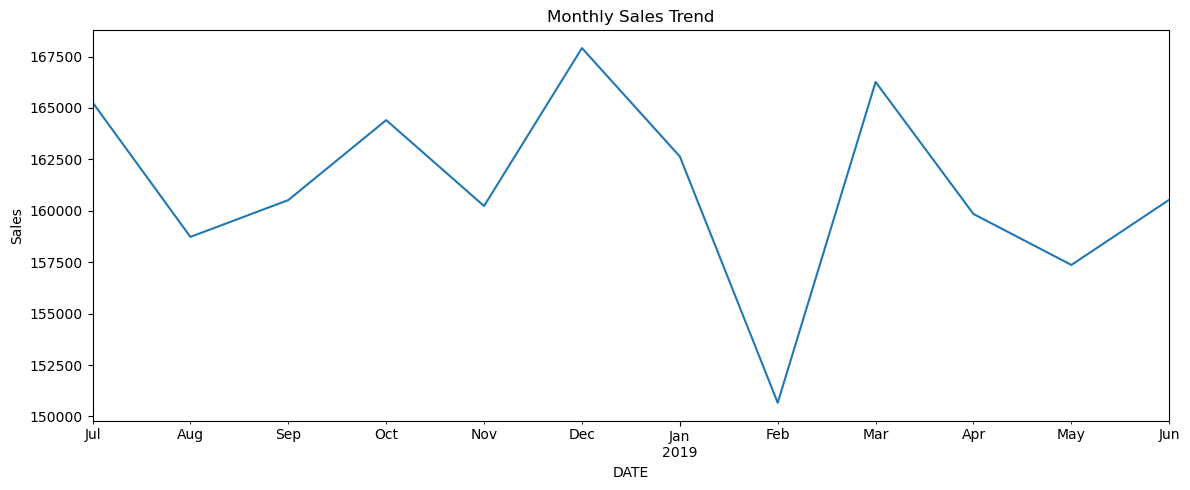

In [83]:
# ==============================
# MONTHLY SALES TREND
# ==============================

try:
    df['DATE'] = pd.to_datetime(
        df['DATE'],
        origin='1899-12-30',
        unit='D'
    )

    monthly_sales = (
        df.groupby(df['DATE'].dt.to_period('M'))
          ['TOT_SALES']
          .sum()
    )

    print("\n\nMONTHLY SALES")
    print(monthly_sales)

    plt.figure(figsize=(12,5))
    monthly_sales.plot()
    plt.title("Monthly Sales Trend")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Date conversion issue:", e)

In [84]:
df['BRAND'] = df['PROD_NAME'].str.split().str[0]

brand_sales = (
    df.groupby('BRAND')
      .agg(
          Sales=('TOT_SALES','sum'),
          Quantity=('PROD_QTY','sum')
      )
      .sort_values('Sales', ascending=False)
)

print(brand_sales.head(15))

              Sales  Quantity
BRAND                        
kettle     390239.8     79051
smiths     210070.8     54728
doritos    201538.9     47707
pringles   177655.5     48019
old         90785.1     17805
thins       88852.5     26929
twisties    81522.1     18118
tostitos    79789.6     18134
infuzions   76247.6     21119
cobs        70569.8     18571
rrd         64954.5     22500
tyrrells    51647.4     12298
grain       43048.8     11962
dorito      40352.0      6509
cheezels    40029.9      8747


In [85]:
pack = (
    df.groupby('WEIGHT')
      .agg(
          Sales=('TOT_SALES','sum'),
          Quantity=('PROD_QTY','sum')
      )
      .sort_values('Sales', ascending=False)
)

print(pack.head(15))

           Sales  Quantity
WEIGHT                    
175     485431.4    126465
150     304288.5     82174
134     177655.5     48019
110     162765.4     42835
170     146673.0     38088
330     136794.3     23999
300     113330.6     28813
165     101360.6     29051
380      76719.6     12673
270      55425.4     12049
210      43048.8     11962
250      26096.7      6069
135      26090.4      6212
200      16007.5      8425
190      14412.9      5673


# Part 2

In [86]:

# get datatypes in df
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264835 entries, 0 to 264834
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264835 non-null  datetime64[ns]
 1   STORE_NBR         264835 non-null  int64         
 2   LYLTY_CARD_NBR    264835 non-null  int64         
 3   TXN_ID            264835 non-null  int64         
 4   PROD_NBR          264835 non-null  object        
 5   PROD_NAME         264835 non-null  object        
 6   PROD_QTY          264835 non-null  int64         
 7   TOT_SALES         264835 non-null  float64       
 8   prod_name_lower   264835 non-null  object        
 9   ends_with_weight  264835 non-null  bool          
 10  WEIGHT            264835 non-null  int64         
 11  LIFESTAGE         264835 non-null  object        
 12  PREMIUM_CUSTOMER  264835 non-null  object        
 13  BRAND             264835 non-null  object        
dtypes: b

In [87]:
import pandas as pd
import numpy as np

df['YEARMONTH'] = df['DATE'].dt.strftime('%Y%m')

store_monthly = (
    df.groupby(['STORE_NBR','YEARMONTH'])
      .agg(
          TOT_SALES=('TOT_SALES','sum'),
          N_CUSTOMERS=('LYLTY_CARD_NBR','nunique'),
          N_TXNS=('TXN_ID','nunique')
      )
      .reset_index()
)

store_monthly['TXN_PER_CUSTOMER'] = (
    store_monthly['N_TXNS'] /
    store_monthly['N_CUSTOMERS']
)

print(store_monthly.head())
print(store_monthly.shape)

   STORE_NBR YEARMONTH  TOT_SALES  N_CUSTOMERS  N_TXNS  TXN_PER_CUSTOMER
0          1    201807      206.9           49      52          1.061224
1          1    201808      176.1           42      43          1.023810
2          1    201809      278.8           59      62          1.050847
3          1    201810      188.1           44      45          1.022727
4          1    201811      192.6           46      47          1.021739
(3169, 6)


In [88]:
store_counts = (
    store_monthly.groupby('STORE_NBR')['YEARMONTH']
    .nunique()
    .sort_values()
)

print(store_counts.value_counts())

YEARMONTH
12    260
2       5
1       3
11      3
3       1
Name: count, dtype: int64


In [89]:
pretrial = store_monthly[
    store_monthly['YEARMONTH'] < '201902'
].copy()

print(pretrial['YEARMONTH'].unique())

['201807' '201808' '201809' '201810' '201811' '201812' '201901']


In [90]:
def calculate_correlation(input_table,
                          metric_col,
                          trial_store):

    trial_data = input_table[
        input_table['STORE_NBR'] == trial_store
    ][['YEARMONTH', metric_col]]

    correlations = []

    for store in input_table['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control = input_table[
            input_table['STORE_NBR'] == store
        ][['YEARMONTH', metric_col]]

        merged = trial_data.merge(
            control,
            on='YEARMONTH',
            suffixes=('_trial','_control')
        )

        corr = merged[
            f'{metric_col}_trial'
        ].corr(
            merged[f'{metric_col}_control']
        )

        correlations.append(
            [trial_store, store, corr]
        )

    return pd.DataFrame(
        correlations,
        columns=[
            'TRIAL_STORE',
            'CONTROL_STORE',
            'CORRELATION'
        ]
    )

In [91]:
def calculate_magnitude_distance(
        input_table,
        metric_col,
        trial_store):

    trial = input_table[
        input_table['STORE_NBR']==trial_store
    ][['YEARMONTH',metric_col]]

    scores = []

    for store in input_table['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control = input_table[
            input_table['STORE_NBR']==store
        ][['YEARMONTH',metric_col]]

        merged = trial.merge(
            control,
            on='YEARMONTH',
            suffixes=('_trial','_control')
        )

        distance = abs(
            merged[f'{metric_col}_trial']
            -
            merged[f'{metric_col}_control']
        )

        score = 1 - (
            (distance - distance.min()) /
            (distance.max() - distance.min() + 1e-9)
        )

        scores.append([
            trial_store,
            store,
            score.mean()
        ])

    return pd.DataFrame(
        scores,
        columns=[
            'TRIAL_STORE',
            'CONTROL_STORE',
            'MAG_SCORE'
        ]
    )

In [92]:
trial_stores = [77,86,88]

for trial in trial_stores:

    sales_corr = calculate_correlation(
        pretrial,
        'TOT_SALES',
        trial
    )

    sales_mag = calculate_magnitude_distance(
        pretrial,
        'TOT_SALES',
        trial
    )

    customer_corr = calculate_correlation(
        pretrial,
        'N_CUSTOMERS',
        trial
    )

    customer_mag = calculate_magnitude_distance(
        pretrial,
        'N_CUSTOMERS',
        trial
    )

    combined = (
        sales_corr
        .merge(
            sales_mag,
            on=['TRIAL_STORE','CONTROL_STORE']
        )
        .merge(
            customer_corr.rename(
                columns={
                    'CORRELATION':
                    'CUSTOMER_CORR'
                }
            ),
            on=['TRIAL_STORE','CONTROL_STORE']
        )
        .merge(
            customer_mag.rename(
                columns={
                    'MAG_SCORE':
                    'CUSTOMER_MAG'
                }
            ),
            on=['TRIAL_STORE','CONTROL_STORE']
        )
    )

    combined['FINAL_SCORE'] = (
        combined['CORRELATION']
        +
        combined['MAG_SCORE']
        +
        combined['CUSTOMER_CORR']
        +
        combined['CUSTOMER_MAG']
    ) / 4

    print(f"\nTRIAL STORE {trial}")
    print(
        combined
        .sort_values(
            'FINAL_SCORE',
            ascending=False
        )
        .head(10)
    )

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\sit


TRIAL STORE 77
     TRIAL_STORE  CONTROL_STORE  CORRELATION  MAG_SCORE  CUSTOMER_CORR  \
230           77            233     0.903774   0.490806       0.990358   
70            77             71     0.914106   0.664887       0.754817   
82            77             84     0.684348   0.629596       0.858571   
116           77            119     0.867664   0.404428       0.983267   
112           77            115     0.689159   0.727536       0.718882   
49            77             50     0.763866   0.630361       0.607391   
2             77              3     0.806644   0.522914       0.834207   
40            77             41     0.783232   0.491685       0.844219   
262           77            265     0.639759   0.678571       0.573460   
16            77             17     0.842668   0.409456       0.747308   

     CUSTOMER_MAG  FINAL_SCORE  
230      0.642857     0.756949  
70       0.571429     0.726310  
82       0.571429     0.685986  
116      0.476190     0.682887  
112 

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\sit


TRIAL STORE 86
     TRIAL_STORE  CONTROL_STORE  CORRELATION  MAG_SCORE  CUSTOMER_CORR  \
152           86            155     0.877882   0.738330       0.942876   
106           86            109     0.788300   0.605940       0.770778   
111           86            114     0.734415   0.528371       0.855339   
222           86            225     0.617533   0.586150       0.733791   
135           86            138     0.759864   0.426729       0.749701   
237           86            240     0.825066   0.409573       0.576403   
178           86            181     0.607657   0.571478       0.549331   
257           86            260     0.720350   0.397129       0.846502   
219           86            222     0.795075   0.541590       0.458238   
191           86            194     0.476578   0.684092       0.559963   

     CUSTOMER_MAG  FINAL_SCORE  
152      0.523810     0.770724  
106      0.714286     0.719826  
111      0.471429     0.647389  
222      0.634921     0.643099  
135 

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\sit


TRIAL STORE 88
     TRIAL_STORE  CONTROL_STORE  CORRELATION  MAG_SCORE  CUSTOMER_CORR  \
175           88            178     0.731857   0.569749       0.939466   
13            88             14     0.698557   0.593571       0.942976   
131           88            134     0.864293   0.685875       0.508880   
234           88            237     0.308479   0.595469       0.947326   
184           88            187     0.599076   0.634428       0.671264   
250           88            253     0.811838   0.521990       0.500962   
34            88             35     0.150801   0.654197       0.899594   
201           88            204     0.885774   0.509249       0.550263   
68            88             69     0.450029   0.464062       0.815792   
40            88             41     0.290319   0.562729       0.721650   

     CUSTOMER_MAG  FINAL_SCORE  
175      0.476190     0.679316  
13       0.428571     0.665919  
131      0.571429     0.657619  
234      0.607143     0.614604  
184 

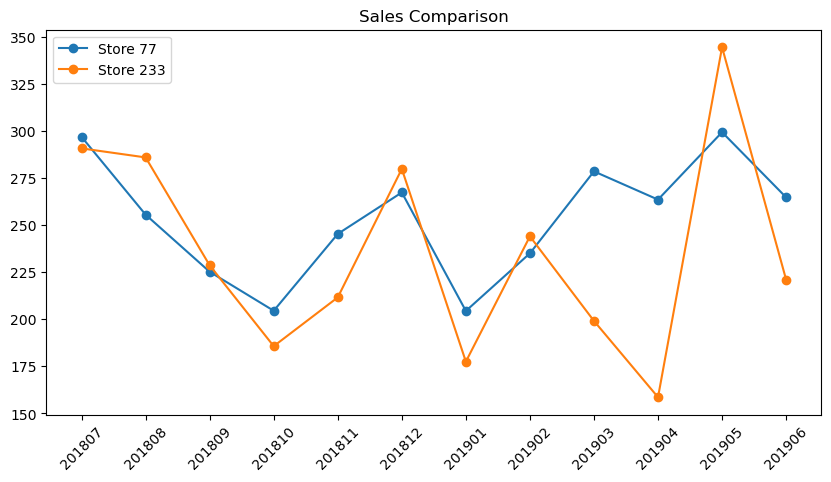

In [93]:
trial_store = 77
control_store = 233  # replace

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    subset = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        subset['YEARMONTH'],
        subset['TOT_SALES'],
        marker='o',
        label=f'Store {store}'
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Sales Comparison")
plt.show()

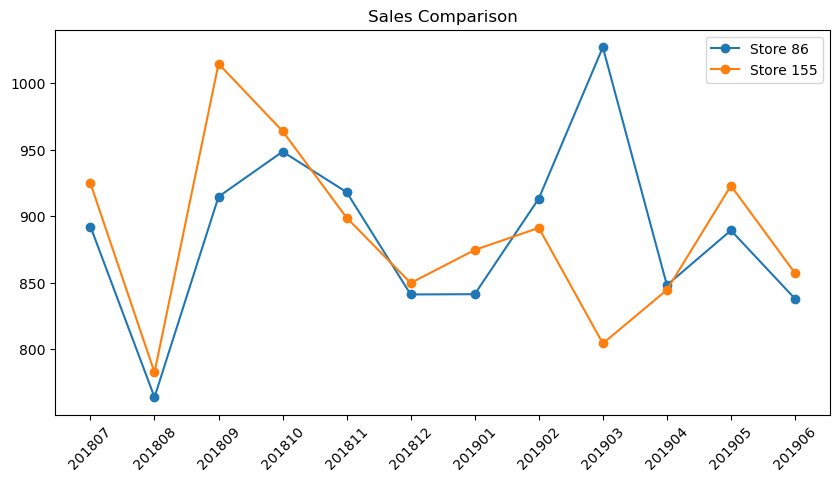

In [94]:
trial_store = 86
control_store = 155  # replace

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    subset = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        subset['YEARMONTH'],
        subset['TOT_SALES'],
        marker='o',
        label=f'Store {store}'
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Sales Comparison")
plt.show()

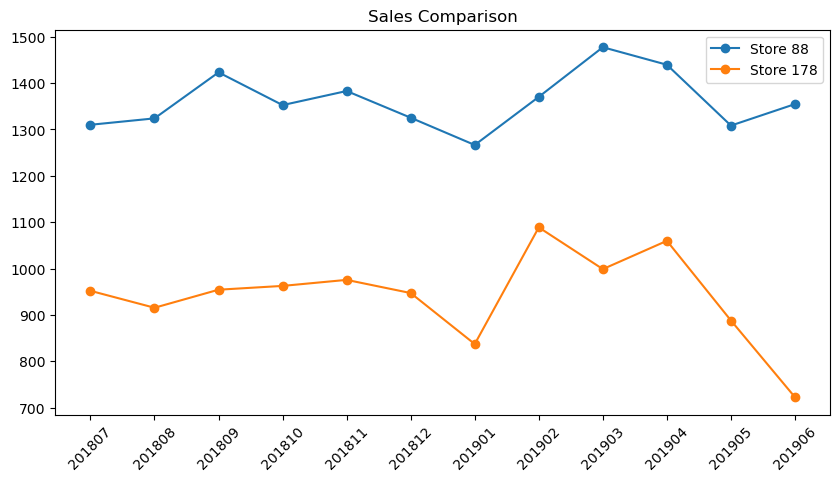

In [95]:
trial_store = 88
control_store = 178  # replace

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    subset = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        subset['YEARMONTH'],
        subset['TOT_SALES'],
        marker='o',
        label=f'Store {store}'
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Sales Comparison")
plt.show()

In [96]:
from scipy.stats import ttest_ind

trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

trial_sales = trial_period[
    trial_period['STORE_NBR']==77
]['TOT_SALES']

control_sales = trial_period[
    trial_period['STORE_NBR']==233
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0590935477424306
P-value: 0.3389336098077161


In [107]:
from scipy.stats import ttest_ind

trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

trial_sales = trial_period[
    trial_period['STORE_NBR']==86
]['TOT_SALES']

control_sales = trial_period[
    trial_period['STORE_NBR']==155
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.9914861460518972
P-value: 0.3567116251995605


In [108]:
from scipy.stats import ttest_ind

trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

trial_sales = trial_period[
    trial_period['STORE_NBR']==88
]['TOT_SALES']

control_sales = trial_period[
    trial_period['STORE_NBR']==178
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.97551183716088
P-value: 0.001279899432293259


# Analysis

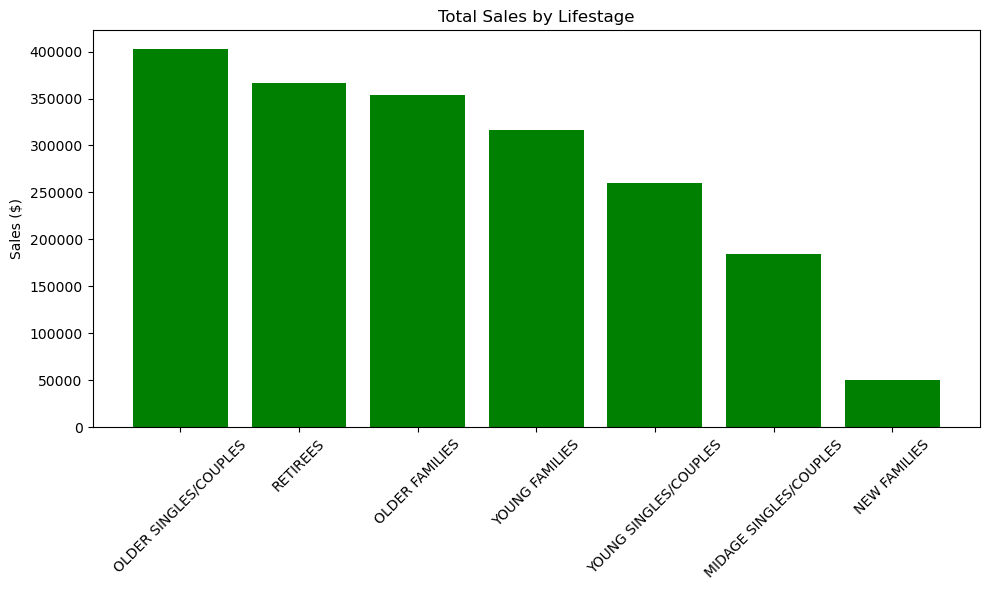

In [98]:
import matplotlib.pyplot as plt

lifestage_sales = (
    df.groupby('LIFESTAGE')['TOT_SALES']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    lifestage_sales.index,
    lifestage_sales.values,
    color='green'
)

plt.title('Total Sales by Lifestage')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

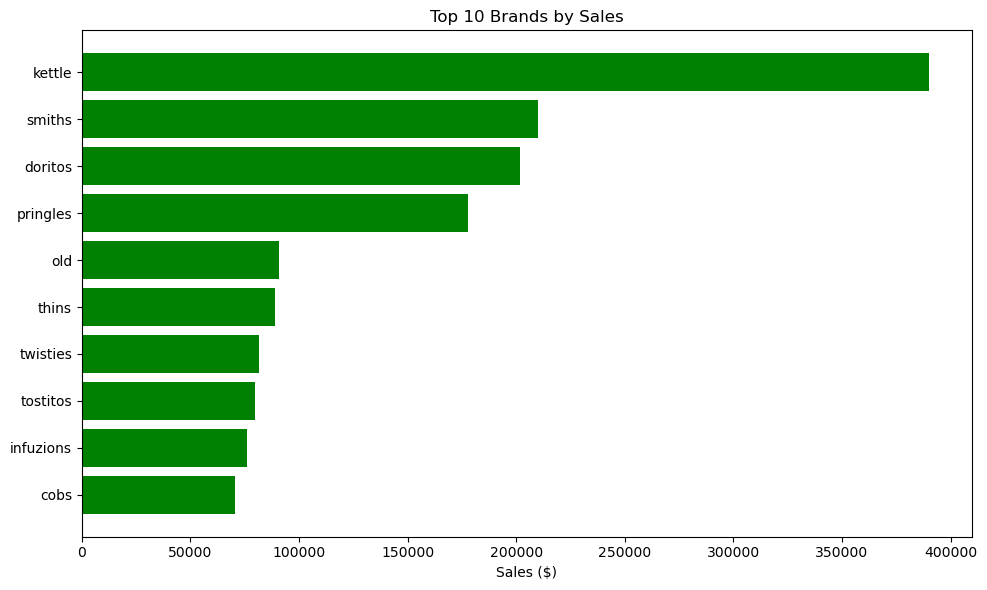

In [99]:
brand_sales = (
    df.groupby('BRAND')['TOT_SALES']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    brand_sales.index[::-1],
    brand_sales.values[::-1],
    color='green'
)

plt.title('Top 10 Brands by Sales')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.show()

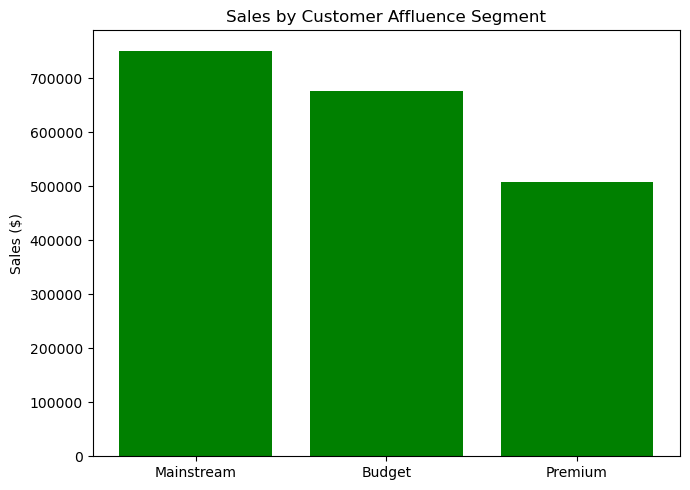

In [100]:
premium_sales = (
    df.groupby('PREMIUM_CUSTOMER')['TOT_SALES']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

plt.bar(
    premium_sales.index,
    premium_sales.values,
    color='green'
)

plt.title('Sales by Customer Affluence Segment')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

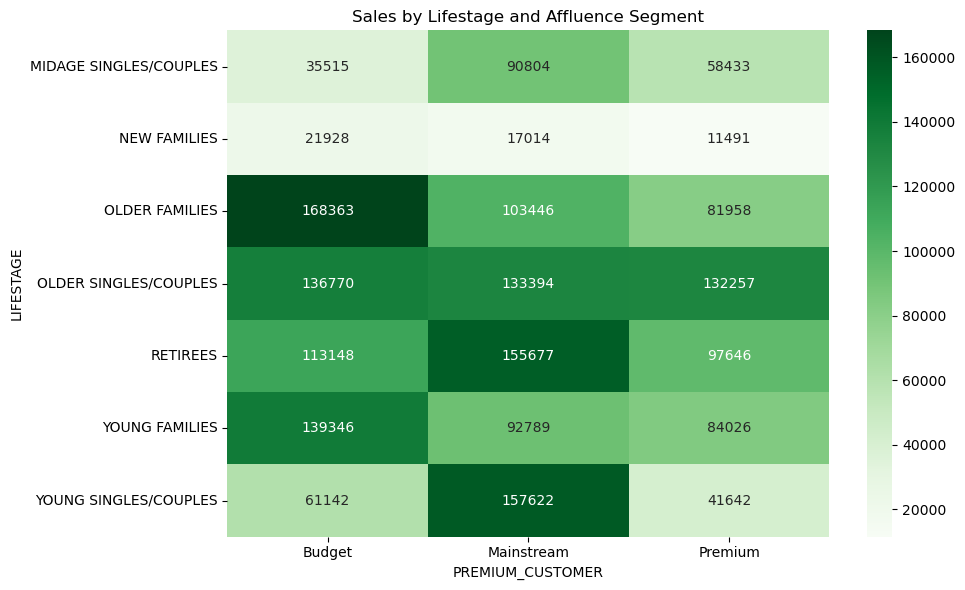

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

heat_data = pd.pivot_table(
    df,
    values='TOT_SALES',
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.0f',
    cmap='Greens'
)

plt.title(
    'Sales by Lifestage and Affluence Segment'
)

plt.tight_layout()
plt.show()

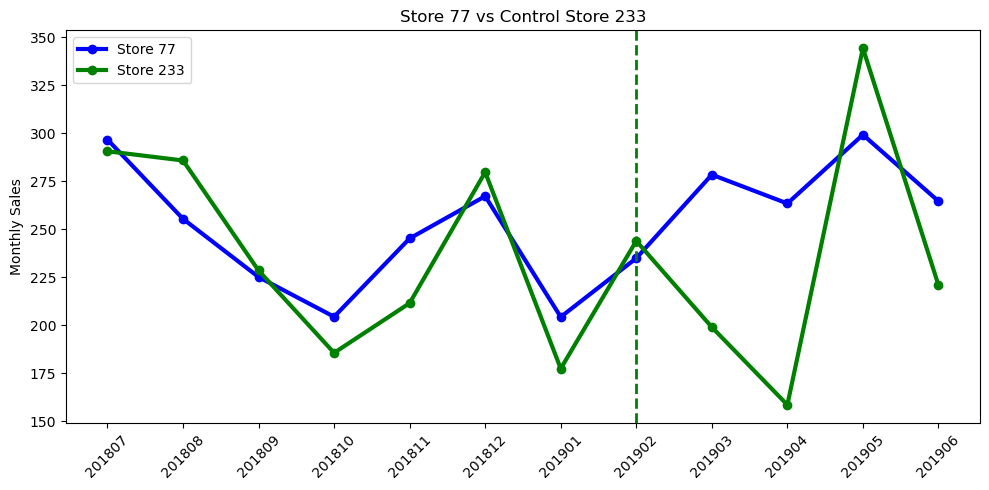

In [105]:
trial_store = 77
control_store = 233

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    temp = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        temp['YEARMONTH'],
        temp['TOT_SALES'],
        marker='o',
        linewidth=3,
        label=f'Store {store}',
        color='blue' if store==trial_store else 'green'
    )

plt.axvline(
    x='201902',
    color='green',
    linestyle='--',
    linewidth=2
)

plt.title(
    'Store 77 vs Control Store 233'
)

plt.ylabel('Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

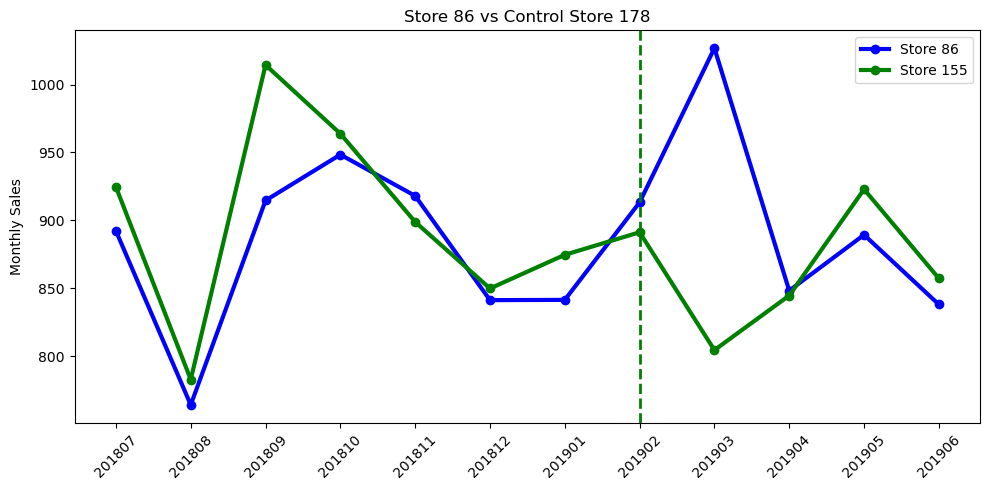

In [116]:
trial_store = 86
control_store = 155

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    temp = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        temp['YEARMONTH'],
        temp['TOT_SALES'],
        marker='o',
        linewidth=3,
        label=f'Store {store}',
        color='blue' if store==trial_store else 'green'
    )

plt.axvline(
    x='201902',
    color='green',
    linestyle='--',
    linewidth=2
)

plt.title(
    'Store 86 vs Control Store 178'
)

plt.ylabel('Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

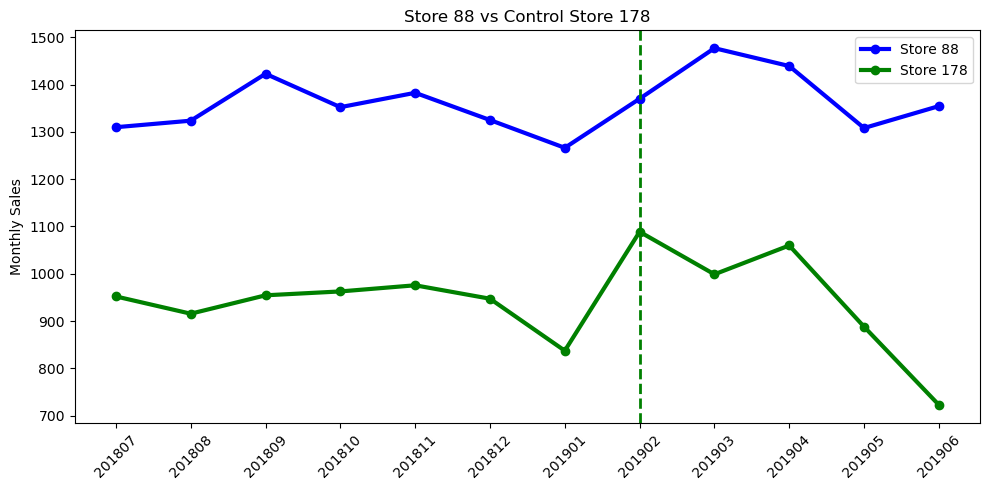

In [117]:
trial_store = 88
control_store = 178

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    temp = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        temp['YEARMONTH'],
        temp['TOT_SALES'],
        marker='o',
        linewidth=3,
        label=f'Store {store}',
        color='blue' if store==trial_store else 'green'
    )

plt.axvline(
    x='201902',
    color='green',
    linestyle='--',
    linewidth=2
)

plt.title(
    'Store 88 vs Control Store 178'
)

plt.ylabel('Monthly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
trial_store = 77
control_store = 233

# Pre-trial period
pretrial = store_monthly[
    store_monthly['YEARMONTH'] < '201902'
]

trial_pre = pretrial[
    pretrial['STORE_NBR'] == trial_store
]['TOT_SALES'].sum()

control_pre = pretrial[
    pretrial['STORE_NBR'] == control_store
]['TOT_SALES'].sum()

scaling_factor = trial_pre / control_pre

# Trial period
trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

control_trial = trial_period[
    trial_period['STORE_NBR'] == control_store
].copy()

control_trial['EXPECTED_SALES'] = (
    control_trial['TOT_SALES'] * scaling_factor
)

actual_trial = trial_period[
    trial_period['STORE_NBR'] == trial_store
][['YEARMONTH', 'TOT_SALES']]

comparison = actual_trial.merge(
    control_trial[['YEARMONTH', 'EXPECTED_SALES']],
    on='YEARMONTH'
)

comparison['PCT_DIFF'] = (
    (comparison['TOT_SALES'] - comparison['EXPECTED_SALES'])
    / comparison['EXPECTED_SALES']
) * 100

print(comparison)

  YEARMONTH  TOT_SALES  EXPECTED_SALES   PCT_DIFF
0    201902      235.0      249.762622  -5.910661
1    201903      278.5      203.802205  36.652103
2    201904      263.5      162.345704  62.307960
3    201905      299.3      352.533799 -15.100339
4    201906      264.7      226.219424  17.010288


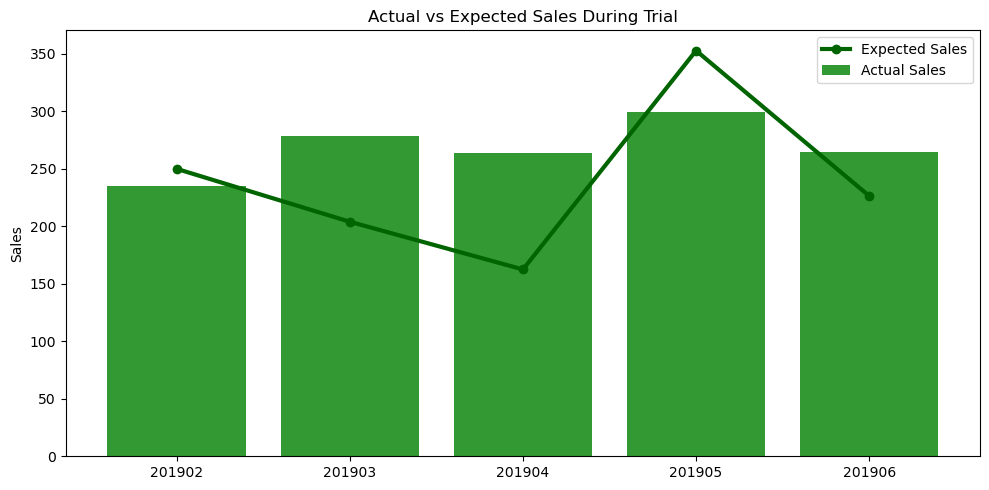

In [113]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison['YEARMONTH'],
    comparison['TOT_SALES'],
    color='green',
    alpha=0.8,
    label='Actual Sales'
)

plt.plot(
    comparison['YEARMONTH'],
    comparison['EXPECTED_SALES'],
    color='darkgreen',
    marker='o',
    linewidth=3,
    label='Expected Sales'
)

plt.title(
    'Actual vs Expected Sales During Trial'
)

plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

  YEARMONTH  TOT_SALES  EXPECTED_SALES   PCT_DIFF
0    201902      913.2      864.522060   5.630619
1    201903     1026.8      780.320405  31.586973
2    201904      848.2      819.317024   3.525250
3    201905      889.3      895.224622  -0.661803
4    201906      838.0      831.539845   0.776891


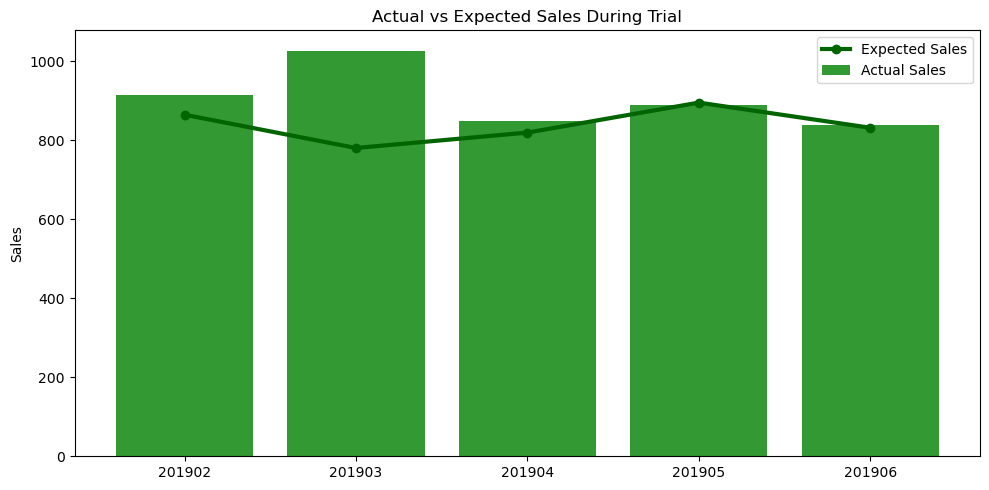

In [114]:
trial_store = 86
control_store = 155

# Pre-trial period
pretrial = store_monthly[
    store_monthly['YEARMONTH'] < '201902'
]

trial_pre = pretrial[
    pretrial['STORE_NBR'] == trial_store
]['TOT_SALES'].sum()

control_pre = pretrial[
    pretrial['STORE_NBR'] == control_store
]['TOT_SALES'].sum()

scaling_factor = trial_pre / control_pre

# Trial period
trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

control_trial = trial_period[
    trial_period['STORE_NBR'] == control_store
].copy()

control_trial['EXPECTED_SALES'] = (
    control_trial['TOT_SALES'] * scaling_factor
)

actual_trial = trial_period[
    trial_period['STORE_NBR'] == trial_store
][['YEARMONTH', 'TOT_SALES']]

comparison = actual_trial.merge(
    control_trial[['YEARMONTH', 'EXPECTED_SALES']],
    on='YEARMONTH'
)

comparison['PCT_DIFF'] = (
    (comparison['TOT_SALES'] - comparison['EXPECTED_SALES'])
    / comparison['EXPECTED_SALES']
) * 100

print(comparison)

plt.figure(figsize=(10,5))

plt.bar(
    comparison['YEARMONTH'],
    comparison['TOT_SALES'],
    color='green',
    alpha=0.8,
    label='Actual Sales'
)

plt.plot(
    comparison['YEARMONTH'],
    comparison['EXPECTED_SALES'],
    color='darkgreen',
    marker='o',
    linewidth=3,
    label='Expected Sales'
)

plt.title(
    'Actual vs Expected Sales During Trial'
)

plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

  YEARMONTH  TOT_SALES  EXPECTED_SALES   PCT_DIFF
0    201902    1370.20     1561.137395 -12.230659
1    201903    1477.20     1432.094076   3.149648
2    201904    1439.40     1519.556770  -5.275010
3    201905    1308.25     1273.227412   2.750694
4    201906    1354.60     1036.074469  30.743498


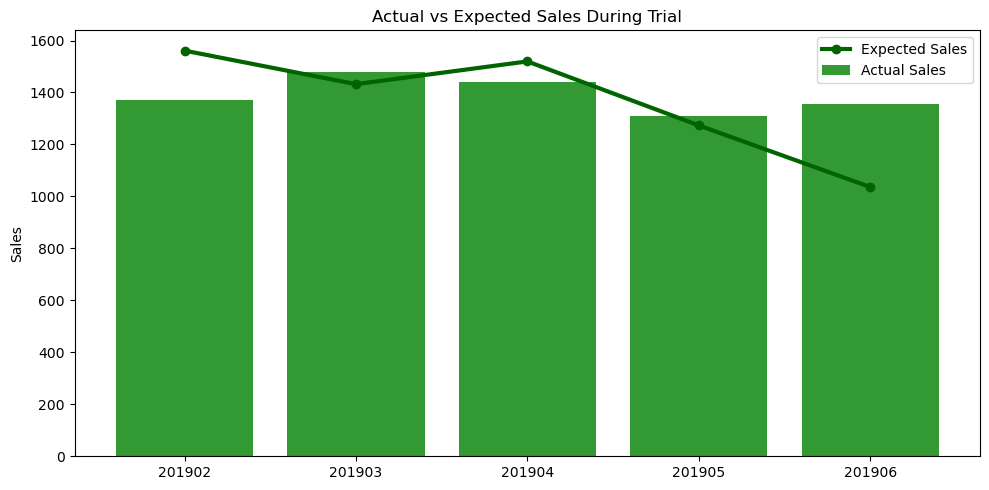

In [115]:
trial_store = 88
control_store = 178

# Pre-trial period
pretrial = store_monthly[
    store_monthly['YEARMONTH'] < '201902'
]

trial_pre = pretrial[
    pretrial['STORE_NBR'] == trial_store
]['TOT_SALES'].sum()

control_pre = pretrial[
    pretrial['STORE_NBR'] == control_store
]['TOT_SALES'].sum()

scaling_factor = trial_pre / control_pre

# Trial period
trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

control_trial = trial_period[
    trial_period['STORE_NBR'] == control_store
].copy()

control_trial['EXPECTED_SALES'] = (
    control_trial['TOT_SALES'] * scaling_factor
)

actual_trial = trial_period[
    trial_period['STORE_NBR'] == trial_store
][['YEARMONTH', 'TOT_SALES']]

comparison = actual_trial.merge(
    control_trial[['YEARMONTH', 'EXPECTED_SALES']],
    on='YEARMONTH'
)

comparison['PCT_DIFF'] = (
    (comparison['TOT_SALES'] - comparison['EXPECTED_SALES'])
    / comparison['EXPECTED_SALES']
) * 100

print(comparison)

plt.figure(figsize=(10,5))

plt.bar(
    comparison['YEARMONTH'],
    comparison['TOT_SALES'],
    color='green',
    alpha=0.8,
    label='Actual Sales'
)

plt.plot(
    comparison['YEARMONTH'],
    comparison['EXPECTED_SALES'],
    color='darkgreen',
    marker='o',
    linewidth=3,
    label='Expected Sales'
)

plt.title(
    'Actual vs Expected Sales During Trial'
)

plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()